## Natural Language Processing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gensim import corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import *
import spacy
from spacy.util import minibatch
from spacy.training.example import Example
import en_core_web_sm
from spacytextblob.spacytextblob import SpacyTextBlob

/Users/olivergormley/mambaforge/envs/mlds/lib/python3.10/site-packages/spacy/util.py:971: UserWarning: [W095] Model 'en_core_web_sm' (3.7.1) was trained with spaCy v3.7.2 and may not be 100% compatible with the current version (3.8.15). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


### Latent Semantic Analysis of Recipes

Latent Semantic Analysis (LSA) is a natural language processing and statistical technique used to find hidden (latent) relationships between words or documents. By assuming words used in similar contexts share similar meanings, LSA builds a term-document matrix and applies singular value decomposition to reduce dimensionality and uncover underlying conceptual topics.

In this project I will apply LSA on a recipe book to identify semantically similar words.

#### Text Preprocessing

In [3]:
# load the first 1000 recipes
recipe_data = pd.read_csv("RAW_recipes.csv")
recipes = recipe_data['description']

In [4]:
recipes[0:3]

0    autumn is my favorite time of year to cook! th...
1    this recipe calls for the crust to be prebaked...
2    this modified version of 'mom's' chili was a h...
Name: description, dtype: object

In [5]:
# Remove NaNs or non-string values
recipes_cleaned = recipes.dropna().loc[recipes.apply(lambda x: isinstance(x, str))]
recipes_cleaned.head()

0    autumn is my favorite time of year to cook! th...
1    this recipe calls for the crust to be prebaked...
2    this modified version of 'mom's' chili was a h...
3    this is a super easy, great tasting, make ahea...
4    my dh's amish mother raised him on this recipe...
Name: description, dtype: object

In [6]:
# Removing symbols and urls
recipes_cleaned=recipes_cleaned.str.replace(r'^https?:\/\/.*[\r\n]*', '', regex=True)
recipes_cleaned = recipes_cleaned.str.replace("[^A-Za-z0-9-]", " ", regex=True)
recipes_cleaned = recipes_cleaned.str.replace("[0â€“9]"," ", regex=True)
recipes_cleaned = recipes_cleaned.str.replace("[^a-zA-Z#]", " ", regex=True)

remove_list = [
    "recipe", "recipes",
    "cook", "cooks", "cooked", "cooking",
    "ingredient", "ingredients",
    "condiment", "condiments",
    "make", "made",
    "do",
    "use", "used", "using",
    "add", "added",
    "put",
    "get",
    "take", "taken",
    "time",
    "taste",
    "well",
    "good", "great",
    "place",
    "serve", "served", "serving",
    "dish",
    "mixture",
    "love",
    "easy",
    "simple",
    "best",
    "favorite",
    "perfect",
    "delicious",
    "also",
    "year",
    "like",
    "one",
    "lb"
]
for word in remove_list:
    recipes_cleaned = recipes_cleaned.str.replace(word, " ")

#### Tokenisation

In [7]:
nltk.download('stopwords')
english_stop_words = set(stopwords.words('english'))

# tokenise recipes
recipes_tokenised = recipes_cleaned.apply(lambda x: x.split())

# Stemming
stemmer = PorterStemmer()
recipes_tok = recipes_tokenised.apply(lambda x: [stemmer.stem(i) for i in x if i not in english_stop_words]) # stemming
recipes_tok.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/olivergormley/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


0    [autumn, prepar, either, spici, sweet, choic, ...
1    [call, crust, prebak, bit, ing, feel, free, ch...
2    [modifi, version, mom, chili, hit, christma, p...
3    [super, tast, ahead, side, look, spent, lot, p...
4    [dh, amish, mother, rais, much, prefer, store,...
Name: description, dtype: object

In [8]:
# Create a corpus
dictionary = corpora.Dictionary(recipes_tok)
corpus = [dictionary.doc2bow(doc) for doc in recipes_tok]

#### Coherence Scores

In Latent Semantic Analysis, coherence scores measure how semantically related the words within each latent topic are. It measures how well the top words in a topic belong together.

Below I calculate coherence scores for a range of topics from 1 to 20 in order to evaluate the optimal number of topics in the recipes.

In [17]:
# set a maximum number of topics to calculate coherence scores for
max_topics = 10

coherence_values = []
model_list = []
for num_topics in range(1, max_topics+1,1):
    # generate and train LSA model
    model = LsiModel(corpus , num_topics=num_topics, id2word = dictionary, random_seed=100)
    model_list.append(model)
    # calculate coherence scores
    coherencemodel = CoherenceModel(model=model, texts=recipes_tok, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherencemodel.get_coherence())


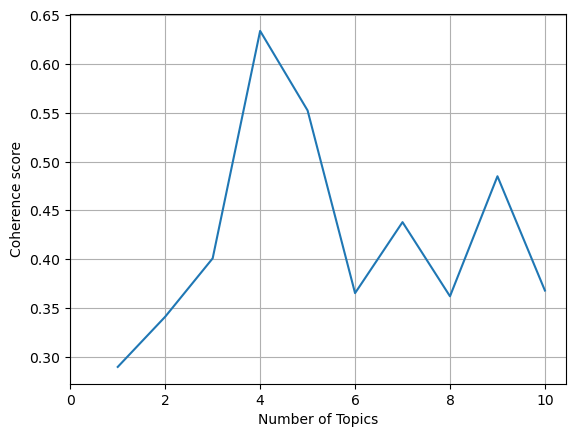

In [18]:
# Show graph
x = range(0, num_topics+1, 2)
plt.plot(range(1, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.xticks(range(0, max_topics+2, 2)) 
plt.ylabel("Coherence score")
plt.grid()
plt.show()

4 topics look optimal as it has the highest coherence score.

In [19]:
# generate LSA model
num_topics=4
words = 10
lsamodel = LsiModel(corpus , num_topics=num_topics, id2word = dictionary)  # train model
print(lsamodel.print_topics(num_topics=num_topics, num_words=words))

[(0, '-0.225*"bread" + -0.199*"tri" + -0.172*"flour" + -0.141*"n" + -0.135*"famili" + -0.130*"salad" + -0.126*"soup" + -0.126*"chicken" + -0.126*"cake" + -0.125*"whole"'), (1, '-0.532*"flour" + -0.478*"bread" + -0.258*"whole" + -0.177*"wheat" + -0.172*"machin" + -0.147*"seed" + -0.136*"loaf" + -0.125*"cup" + -0.119*"grain" + -0.097*"white"'), (2, '-0.444*"cake" + -0.296*"cream" + 0.265*"salad" + 0.244*"soup" + -0.234*"sugar" + -0.180*"tri" + 0.174*"bean" + 0.171*"chicken" + 0.152*"dress" + -0.146*"chocol"'), (3, '0.487*"salad" + 0.375*"dress" + -0.342*"soup" + -0.261*"bean" + 0.159*"top" + 0.112*"amount" + 0.107*"secret" + 0.101*"quantiti" + 0.100*"ring" + 0.099*"tri"')]


In [20]:
output = lsamodel.print_topics(num_topics=num_topics, num_words=words)

Next I plot the 10 words with highest weights in each topic, in order to draw an interpretation of the topics.

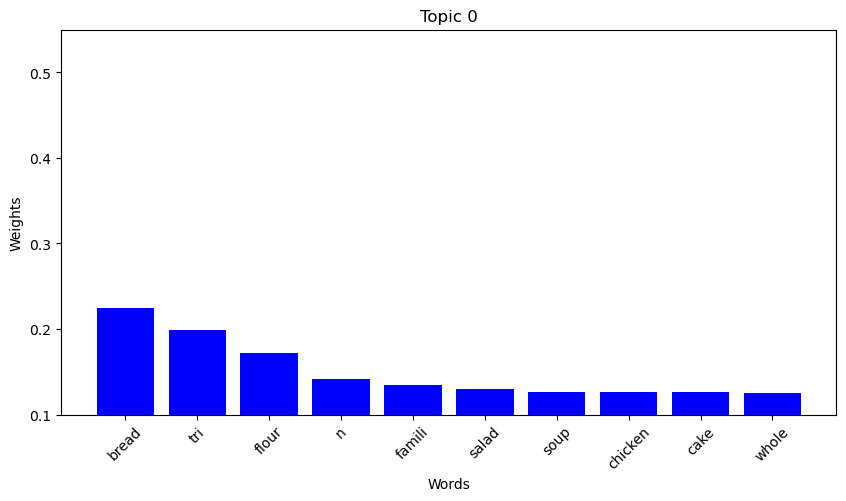

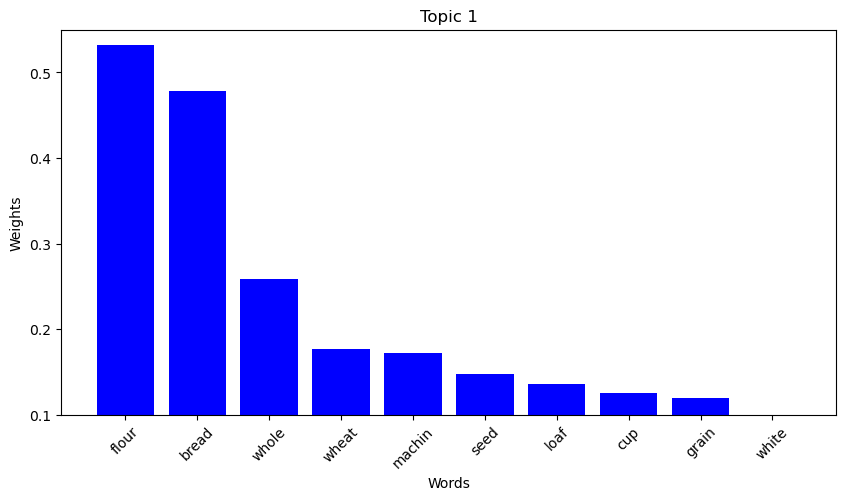

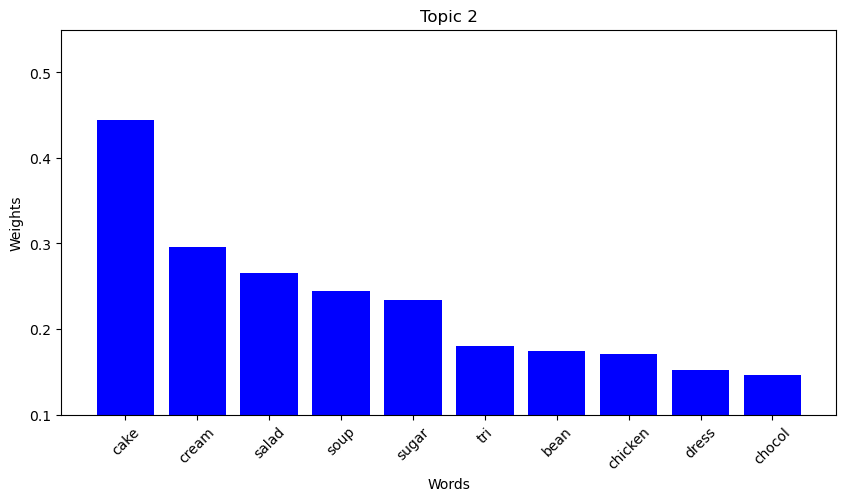

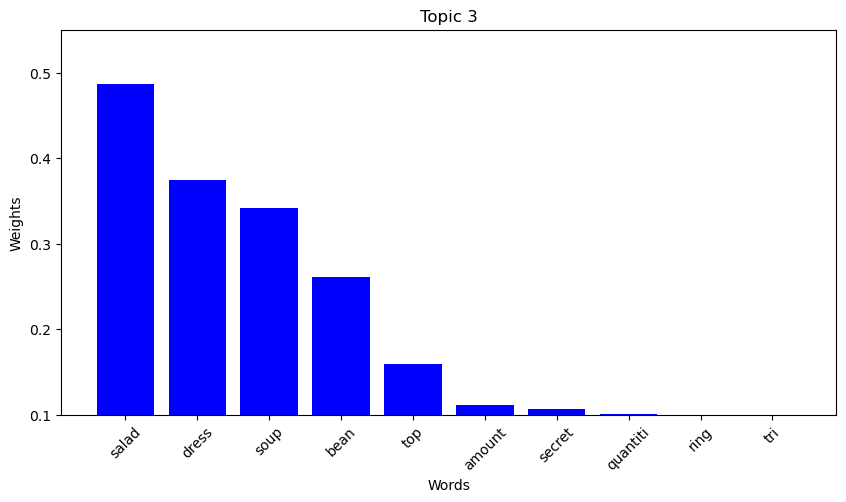

In [21]:
# Function to parse the output
def parse_lsa_output(output):
    topics = {}
    for topic_num, topic in output:
        matches = re.findall(r"(\d\.\d+)\*\"([^\"]+)\"", topic)
        topics[topic_num] = [(word, float(weight)) for weight, word in matches]
    return topics

# Parse the LSA model output
parsed_topics = parse_lsa_output(output)

# Plotting
for topic_num, words_weights in parsed_topics.items():
    words, weights = zip(*words_weights)
    plt.figure(figsize=(10, 5))
    plt.bar(words, weights, color='blue')
    plt.xlabel('Words')
    plt.ylabel('Weights')
    plt.title(f'Topic {topic_num}')
    plt.xticks(rotation=45)
    plt.yticks(np.arange(0.0, 1.0, 0.1))
    plt.ylim(0.1, 0.55) 
    plt.show()


My interpretation of the topics based on the displayed words is as below:

- Topic 0 does not have an obvious theme, with a mix of lunch items (bread, salad, soup), baking (flour) and sweet items (cake)
- Topic 1 contains words related to bread and savoury baking, possibly baking bread: bread, flour, machine, whole, wheat, loaf
- Topic 2 contains words related to sweet foods: cake, cream, sugar, chocol(ate)
- Topic 3 contains more lunch items and could possibly be vegetarian dishes as no mention of meat or dairy: salad, dress(ing), soup, bean

### Sentiment Analysis of Starbucks Reviews

In this section, I train a text classifier to classify the sentiment of a dataset of Starbucks reviews. I use pre-defined pipelines in spaCy to avoid building a network from zero.

In [22]:
review_data = pd.read_csv("reviews_data.csv")
reviews = review_data['Review']
ratings = review_data['Rating']

In [23]:
reviews[:10]

0    Amber and LaDonna at the Starbucks on Southwes...
1    ** at the Starbucks by the fire station on 436...
2    I just wanted to go out of my way to recognize...
3    Me and my friend were at Starbucks and my card...
4    I’m on this kick of drinking 5 cups of warm wa...
5    We had to correct them on our order 3 times. T...
6    I have tried Starbucks several different times...
7    Starbucks near me just launched new fall foods...
8    I ordered online for the Reisterstown Rd, St T...
9    Staff at the Smythe St. Superstore location in...
Name: Review, dtype: object

In [24]:
ratings[:10]

0    5.0
1    5.0
2    5.0
3    5.0
4    5.0
5    1.0
6    1.0
7    1.0
8    1.0
9    1.0
Name: Rating, dtype: float64

In [25]:
ratings.tail()

845   NaN
846   NaN
847   NaN
848   NaN
849   NaN
Name: Rating, dtype: float64

In [26]:
reviews.tail()

845    I ordered two venti frappacino's without whipp...
846                                       No Review Text
847    DEMANDED TIPS FROM ME, THEN MADE ME WAIT UNTIL...
848                                       No Review Text
849                                       No Review Text
Name: Review, dtype: object

#### Preprocess Data

In [27]:
no_text_review_indices = reviews == "No Review Text"
no_rating_indices = np.isnan(ratings)
remove_indices = no_text_review_indices | no_rating_indices

In [28]:
reviews = reviews[~remove_indices]
ratings = ratings[~remove_indices]

In [29]:
len(reviews)

703

In [30]:
len(ratings)

703

In [31]:
def create_sentiment_array(ratings):
    sentiment = []
    for rating in ratings:
        if rating <= 2.0:
            sentiment.append('negative')
        elif rating == 3.0:
            sentiment.append('neutral')
        else:
            sentiment.append('positive')
    return sentiment


# Create the 'sentiment' array
sentiments = create_sentiment_array(ratings)
sentiments[:7]


['positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative']

In [32]:
ratings[:7]

0    5.0
1    5.0
2    5.0
3    5.0
4    5.0
5    1.0
6    1.0
Name: Rating, dtype: float64

Next I set up a spaCy NLP pipeline with TextBlob sentiment analysis.

TextBlob's polarity ranges from approximately −1 to +1 where:

- -1 = strongly negative
- 0 = neutral
- +1 = strongly positive

In [33]:
nlp = spacy.load("en_core_web_sm")
nlp = en_core_web_sm.load()
nlp.add_pipe('spacytextblob')

/Users/olivergormley/mambaforge/envs/mlds/lib/python3.10/site-packages/spacy/util.py:971: UserWarning: [W095] Model 'en_core_web_sm' (3.7.1) was trained with spaCy v3.7.2 and may not be 100% compatible with the current version (3.8.15). If you see errors or degraded performance, download a newer compatible model or retrain your custom model with the current spaCy version. For more details and available updates, run: python -m spacy validate
  warnings.warn(warn_msg)


In [34]:
# Initialize a list for predictions
predictions = [None] * len(reviews)
   
def classify_sentiment(doc, threshold = 0.2):
    doc = nlp(doc)  
    # Check polarity for sentiment
    if doc._.polarity > threshold:
        sentiment = 'positive'
    elif doc._.polarity < -threshold:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    return sentiment

In [35]:
sentiments[:7]

['positive',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative']

Below I apply a range of thresholds for the polarity score in TextBlob and compare prediction accuracy to find the optimal threshold for review sentiment.

In [36]:
thresholds = [0, 0.1, 0.2,0.3, 0.4]

for threshold in thresholds:
      for i, review in enumerate(reviews):
            predictions[i] = classify_sentiment(review, threshold)
      prediction_accuracy = sum(prediction == sentiment for prediction, sentiment in zip(predictions, sentiments))/len(predictions)
      print(f'Threshold: {threshold}, Prediction accuracy: {prediction_accuracy:.2%}')

Threshold: 0, Prediction accuracy: 56.76%
Threshold: 0.1, Prediction accuracy: 38.98%
Threshold: 0.2, Prediction accuracy: 27.45%
Threshold: 0.3, Prediction accuracy: 17.78%
Threshold: 0.4, Prediction accuracy: 11.81%


The best prediction accuracy occurs with a polarity threshold of 0, i.e. only positive or negative sentiments (no neutral category). Hence I remove neutral reviews from my analysis.

In [37]:
sentiments = np.array(sentiments)
non_neutral_indices = np.where(sentiments != 'neutral')
sentiments_non_neutral = sentiments[non_neutral_indices]


In [38]:
reviews = np.array(reviews)
reviews_non_neutral = reviews[non_neutral_indices]

In [39]:
thresholds = [0]
predictions_non_neutral = [None] * len(reviews_non_neutral)

for threshold in thresholds:
      for i, review in enumerate(reviews_non_neutral):
            predictions_non_neutral[i] = classify_sentiment(review, threshold)
      prediction_accuracy = sum(prediction == sentiment for prediction, sentiment in zip(predictions_non_neutral, sentiments_non_neutral))/len(predictions_non_neutral)
      print(f'Threshold: {threshold}, Prediction accuracy: {prediction_accuracy:.2%}')

Threshold: 0, Prediction accuracy: 59.40%


In [40]:
doc1 = "My experience at Starbucks is great"
classify_sentiment(doc1, threshold = 0)

'positive'

In [41]:
doc2 = "The Americano tastes awful"
classify_sentiment(doc2,threshold = 0)

'negative'

Given that the model performed better without a 'neutral' sentiment category, as a last piece of analysis, I take a look at some of the 3 star reviews to see whether they tend to be more positive/negative oriented rather than balanced.

In [42]:
three_star = np.where(review_data['Rating'] == 3)

for review in reviews[three_star][:3]:
    print(review)

In my opinion, I can't believe Starbucks has now changed it to 200 stars for free handcrafted beverage!!! It was 150 so that means spend $150 and you get a free drink! Not anymore. The coffees are already outrageous as it is, they ask you tip now with new card reader which is super uncomfortable in the first place. May start going to 7 Brew, it's good, cheap and 5 minutes from them here in Kingsport.
I am continually disappointed when going to Starbucks. I am not sure they are reading the room… so to speak. The cost Continues to go up… as all things. But there should be a level of competing with the competitor. In our town we have 2 new Dunkin Donuts and they are less expensive. No am sure they are pulling customers. It also seems they are shorting the cups. Do not seem to be full on the craft drinks. Service has been much better than Last year. Have been a consumer for a Long time. Just seem it’s time to feed the customer more obviously than points.
45 minutes in line with the employe

These 3 star 'neutral' categorised reviews are in fact quite negative by sentiment.